# Task 1

## Dataset: Oxford IIT Pet Dataset
Link: https://www.kaggle.com/datasets/tanlikesmath/the-oxfordiiit-pet-dataset?resource=download

### Part 1

**load dataset info**

In [1]:
!pip install -q tensorflow-datasets scikit-learn

import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

# import keras layers/models, mobilenetv2 for transfer learning, and preprocessing/metrics utilities
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# confirm environment setup
print("TensorFlow version:", tf.__version__)

# build Oxford-IIIT pet dataset and download/prepare
builder = tfds.builder("oxford_iiit_pet")
builder.download_and_prepare()

# access dataset structural info
info = builder.info
print(info)
print("Number of classes:", info.features["label"].num_classes)
print("Class names:")
print(info.features["label"].names)

TensorFlow version: 2.19.0


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.J58UF8_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.J58UF8_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='oxford_iiit_pet',
    full_name='oxford_iiit_pet/4.0.0',
    description="""
    The Oxford-IIIT pet dataset is a 37 category pet image dataset with roughly 200
    images for each class. The images have large variations in scale, pose and
    lighting. All images have an associated ground truth annotation of breed and
    species. Additionally, head bounding boxes are provided for the training split,
    allowing using this dataset for simple object detection tasks. In the test
    split, the bounding boxes are empty.
    """,
    homepage='http://www.robots.ox.ac.uk/~vgg/data/pets/',
    data_dir='/root/tensorflow_datasets/oxford_iiit_pet/4.0.0',
    file_format=tfrecord,
    download_size=773.52 MiB,
    dataset_size=773.68 MiB,
    features=FeaturesDict({
        'file_name': Text(shape=(), dtype=string),
       

**set constants**

In [2]:
# set each image to 160 x 160 pixels for MobileNetV2 compatibility, small enough for efficiency but large enough to preserve features
IMG_SIZE = (160, 160)
# standard batch size to balance efficiency and stable gradient updates
BATCH_SIZE = 32
# get number of classes: 37
NUM_CLASSES = info.features["label"].num_classes
# get class labels to help with visualizations
CLASS_NAMES = info.features["label"].names
# let tensorflow automatically optimize dataset performance
AUTOTUNE = tf.data.AUTOTUNE

**load train/val/test splits**

In [3]:
# Split the original training set with 80/20 train/val split and the provided TFDS test set
train_ds_raw, val_ds_raw, test_ds_raw = tfds.load(
    "oxford_iiit_pet",
    split=["train[:80%]", "train[80%:]", "test"],
    # simplify pipeline by returning (image, label) pairs
    as_supervised=True
)

**a preprocess function for part 1 and 3**

In [4]:
# prepares each image before it's passed into the model
def preprocess(image, label):
  # resize all images to same dimension for batching and model input
  image = tf.image.resize(image, IMG_SIZE)
  # convert pixel vals to float32 and scale to within [0,1] for stable training
  image = tf.cast(image, tf.float32) / 255.0
  return image, label

**prepare datasets**

In [5]:
# build training dataset pipeline
train_ds = (
    train_ds_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE) # apply preprocessing function to every image, let tf automatically choose efficient settings
    .shuffle(1000) # randomize order of training samples so model doesn't learn from a fixed ordering
    .batch(BATCH_SIZE) # group images into batches
    .prefetch(AUTOTUNE) # overlap preprocessing and model execution to improve runtime
)

# build validation dataset pipeline
val_ds = (
    val_ds_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# build test dataset pipeline
test_ds = (
    test_ds_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

### **visualize sample images**



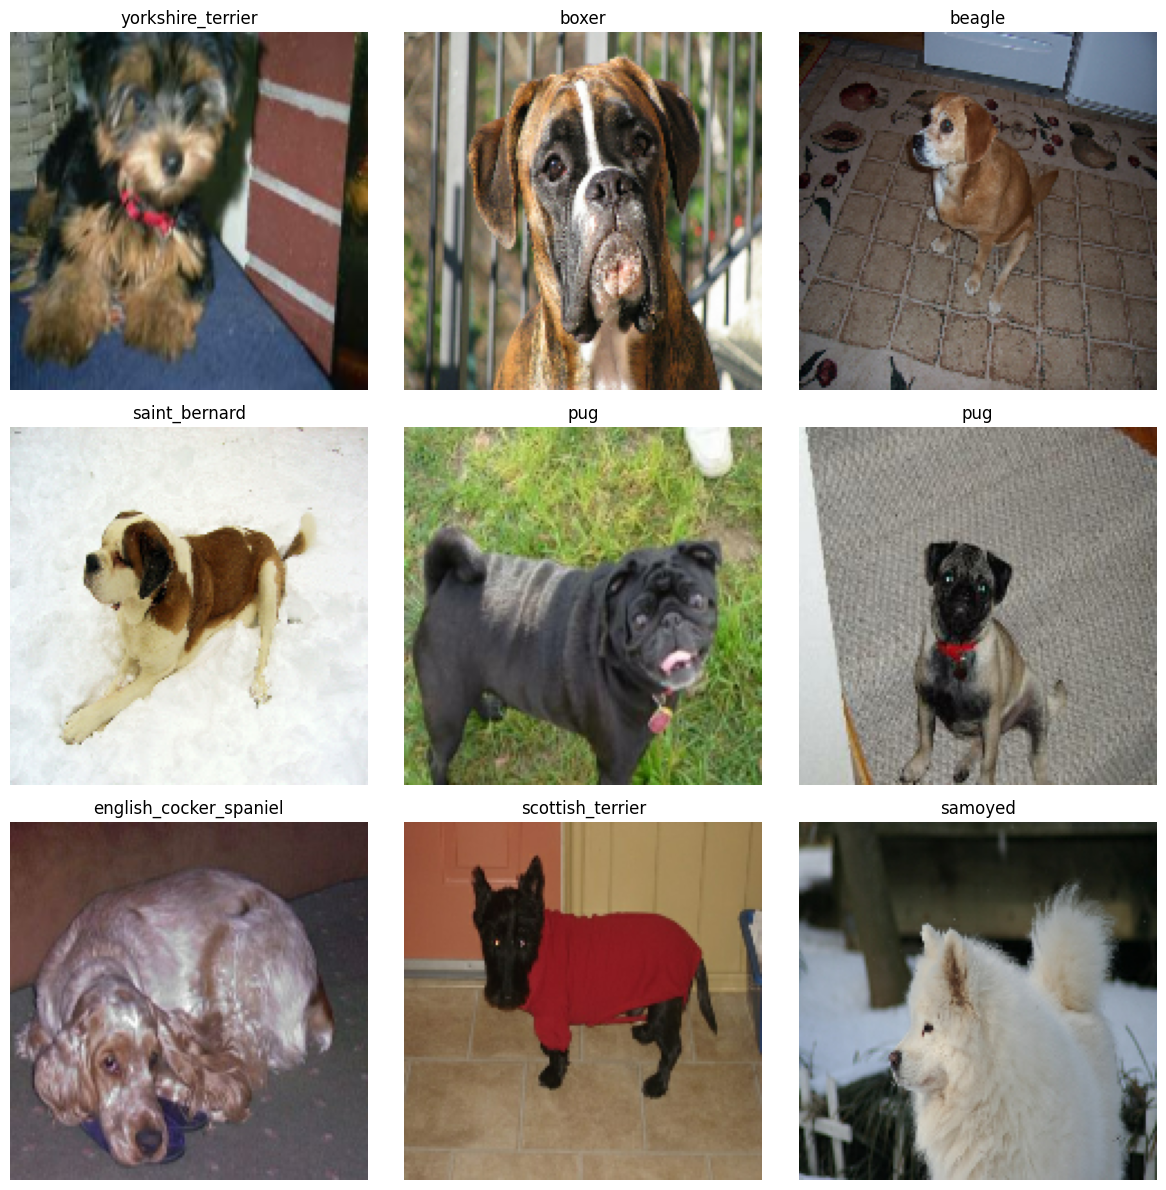

In [6]:
plt.figure(figsize=(12, 12))

# loop over images, labels in first batch
for images, labels in train_ds.take(1):
  # show 9 images
  for i in range(9):
    # place images on 3x3 grid
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy())
    # convert numeric label into actual class label
    plt.title(CLASS_NAMES[labels[i].numpy()])
    plt.axis("off")

plt.tight_layout()
plt.show()

**design choice explanation**

I use a simple, conventional CNN pattern with 3 convolution blocks. Each block consists of a Conv2D layer folowed by a MaxPooling2D layer, and the network ends with a Flatten layer, a Dense layer, and an output layer.

This is a suitable basic pattern because:
1. Early convolution layers learn simple features such as edges and textures
2. Deeper convolution layers learn more complex patterns such as ears, fur, and face shapes
3. MaxPooling reduces spatial size and helps make training more efficient
4. Since this is a 37-class classification problem with moderately complex natural images, a 3-block CNN is a reasonable simple baseline without making the network unnecessarily deep

The final dense layer uses 37 output units with softmax because this is a multiclass classification task.

**build CNN model from scratch**

In [7]:
# defines CNN for multiclass image classification with Keras Sequential
# take sin pet images, learns visual features through convolution + pooling layers, then uses dense layers to classify each image
cnn_model = models.Sequential([
    # define shape of each input image
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)), # images have 3 RGB color channels

    # first conv block: learns simple visual patterns using 32 3x3 filters, then downsamples with 2x2 max pooling to reduce size and computation
    layers.Conv2D(32, (3, 3), activation="relu"), # 32 chosen as standard starting size for first conv layer; 3x3 common filter size
    layers.MaxPooling2D((2, 2)), # 2x2 common way to downsample

    # second conv block: learns more complex patterns using 64 filters
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # third conv block: captures even higher level features with 128 filters without making architecture excessively deep
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(), # convert 3D feature maps from conv layers into a 1D vector bc dense layers expect vector input
    layers.Dense(128, activation="relu"), # hidden layer that combines all extracted features before final classification so model can learn how features relate to target classes
    layers.Dropout(0.3), # randomly turn off 30% of units during training
    layers.Dense(NUM_CLASSES, activation="softmax") # final output layer that gives a probability for each class
])

# show model architecture
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,406,565 (20.62 MB)

 Trainable params: 5,406,565 (20.62 MB)

 Non-trainable params: 0 (0.00 B)

**summary**
<br>
we use a simple, standard CNN with three convolution + max pooling blocks (32, 64, 128) to progressively learn features from low-level to high-level patters, followed by a flatten and dense classifier (128 units and dropout) for final prodiction of the 37 classes. This architecture is efficient, easy to train, and deep enough to capture meaningful features without being overly complex.

### **Compile and train model**

In [8]:
# compile cnn model
cnn_model.compile(
    optimizer="adam", # using adam optimizer as a standard effective choice
    loss="sparse_categorical_crossentropy", # suitable for multi-class classification where labels and ints are integer/not one-hot encoded
    metrics=["accuracy"] # display accuracy each epoch
)

# early stopping callback to prevent overfitting
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", # track validation loss to determine when performance stops improving
    patience=3, # stop training when val loss doesn't improve for 3 consecutive epochs
    restore_best_weights=True # restore model weights from epoch with lowest val loss
)

# train the model
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.0316 - loss: 3.6360 - val_accuracy: 0.0326 - val_loss: 3.6053
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.0513 - loss: 3.5595 - val_accuracy: 0.0679 - val_loss: 3.4914
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.1124 - loss: 3.3017 - val_accuracy: 0.0829 - val_loss: 3.3650
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2154 - loss: 2.8577 - val_accuracy: 0.1359 - val_loss: 3.3997
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3984 - loss: 2.1315 - val_accuracy: 0.1223 - val_loss: 3.6232
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6097 - loss: 1.3770 - val_accuracy: 0.1128 - val_loss: 4.0560


**training curve plot**

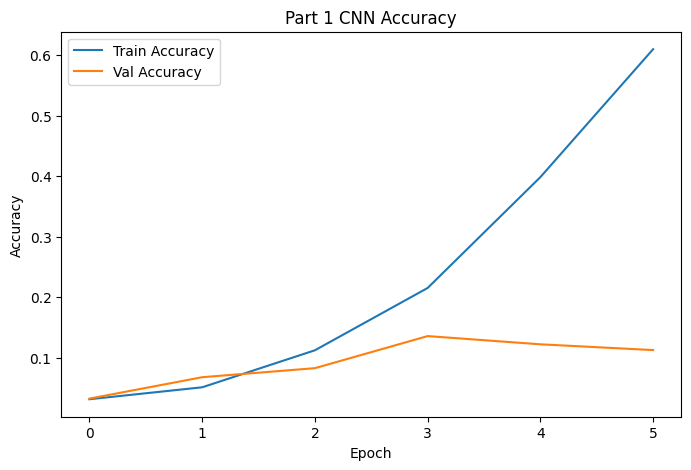

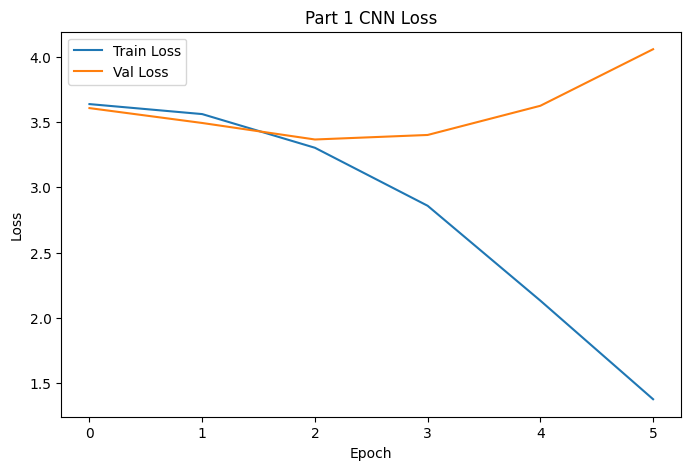

In [9]:
# plot
plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history["accuracy"], label="Train Accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Part 1 CNN Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history["loss"], label="Train Loss")
plt.plot(history_cnn.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part 1 CNN Loss")
plt.legend()
plt.show()

**summary**
<br>
Baseline CNN model is severely overfitting and not generalizing well. Training accuracy rises sharply while val accuracy stays very low. Training loss decreases but val loss increases significantly, indicating poor generalization. Early stopping prevents it from getting even worse.

### **compute metrics**

In [10]:
test_loss, test_accuracy = cnn_model.evaluate(test_ds, verbose=0)

y_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)
y_pred_probs = cnn_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("Part 1 Results")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Weighted Precision:", precision)
print("Weighted Recall:", recall)
print("Weighted F1 Score:", f1)

115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step
Part 1 Results
Test Loss: 3.3890793323516846
Test Accuracy: 0.08994276076555252
Weighted Precision: 0.08675628778450811
Weighted Recall: 0.08994276369582993
Weighted F1 Score: 0.07001712805180652


Overal baseline performance is very low, with 12.9% accuracy. Low precision, recall, and F1 tell us the model does not confidently identify the correct classes, is likely confusing many classes, and is weak across the board, struggling with both false negatives and false positives. Very high loss also confirms poor learning.

**classification report**

In [11]:
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

                            precision    recall  f1-score   support

                Abyssinian       0.09      0.06      0.07        98
          american_bulldog       0.07      0.02      0.03       100
 american_pit_bull_terrier       0.04      0.03      0.04       100
              basset_hound       0.11      0.15      0.13       100
                    beagle       0.08      0.04      0.05       100
                    Bengal       0.20      0.01      0.02       100
                    Birman       0.22      0.04      0.07       100
                    Bombay       0.14      0.43      0.22        88
                     boxer       0.00      0.00      0.00        99
         British_Shorthair       0.00      0.00      0.00       100
                 chihuahua       0.00      0.00      0.00       100
              Egyptian_Mau       0.16      0.04      0.07        97
    english_cocker_spaniel       0.08      0.01      0.02       100
            english_setter       0.03      0.06

### **Evaluate metrics**
<br>
A few model charactertics may explain its poor performance. First, the model was likely too simple for the task, with a basic CNN lacking the complexity to extract refined distinguishing features from each of the 37 classes. Training may also have stopped too early, indicating that early stopping patience may need to be increased. Lack of pretrained features, effective epochs, data augmentation, and sufficient input resolution may also have contributed to this poor performance.

## Part 2

I am choosing MobileNetV2 because it is a widely used pretrained model, efficient, and simple to use in Colab.  
Transfer learning is appropriate here because the pretrained network has already learned useful visual features from a very large image dataset, so it often performs better than a CNN trained from scratch, especially when the project dataset is moderate in size.

**preprocess datasets**

In [12]:
# prepare the train, val, and test datasets in the correct format for the MobileNetV2 transfer learning model

def preprocess_mobilenet(image, label):
  image = tf.image.resize(image, IMG_SIZE)
  image = tf.cast(image, tf.float32)
  image = preprocess_input(image)
  return image, label

# resize, improve pipeline speed, convert image data, group into batches, apply expected preprocessing
train_ds_mn = (
    train_ds_raw
    .map(preprocess_mobilenet, num_parallel_calls=AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds_mn = (
    val_ds_raw
    .map(preprocess_mobilenet, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds_mn = (
    test_ds_raw
    .map(preprocess_mobilenet, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

**build MobileNetV2 model**

In [13]:
# load MobileNetV2 as the pretrained convolutional base
base_model = MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), # resize images with 3 RGB channels
    include_top=False, # remove MobileNetV2's original final classifier layer bc i replace it with my own classifer for this dataset
    weights="imagenet" # use weights learned from imagenet so model starts with useful visual features already learned instead of traning from scratch
)

# freeze pretrained base so its wieghts aren't updated during training; standard trnasfer learning to keep useful learned
# visual features and only train new classification head for specific task
base_model.trainable = False

# build the full transfer learning model
transfer_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    base_model,
    # convert 3D feature maps into 1D feature vector by averaging each feature map
    layers.GlobalAveragePooling2D(), # common choice for transfer learning
    layers.Dense(128, activation="relu"), # 128 units is learge enough to learn but small enough to stay efficient
    layers.Dropout(0.3), # standard dropout rate
    layers.Dense(NUM_CLASSES, activation="softmax")
])

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,725 (9.26 MB)

 Trainable params: 168,741 (659.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**summary**  
uses MobileNetV2 as a pretrained convolutional base with ImageNet weights, configured so only feature extraction layers ar eused. Outputs feature maps of shape 5 x 5 x 1280 for each image. A small fully connected classification head is added:  
- Dense layer with 128 units and ReLU activiation
- a dropout layer
- a final dense layer with 37 units and softmax activation for multiclass classification

**compile and train model**

In [14]:
transfer_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_transfer = transfer_model.fit(
    train_ds_mn,
    validation_data=val_ds_mn,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 69ms/step - accuracy: 0.5866 - loss: 1.5430 - val_accuracy: 0.8451 - val_loss: 0.5133
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8614 - loss: 0.4556 - val_accuracy: 0.8736 - val_loss: 0.4037
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9134 - loss: 0.2817 - val_accuracy: 0.8764 - val_loss: 0.3663
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9450 - loss: 0.1951 - val_accuracy: 0.8832 - val_loss: 0.3562
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9558 - loss: 0.1390 - val_accuracy: 0.8777 - val_loss: 0.3763
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9660 - loss: 0.1168 - val_accuracy: 0.8967 - val_loss: 0.3333
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9783 - loss: 0.0865 - val_accuracy: 0.9035 - val_loss: 0.3378
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9810 - loss: 0.0706 - val_accuracy: 0.8940 - 

**plot learning curve**

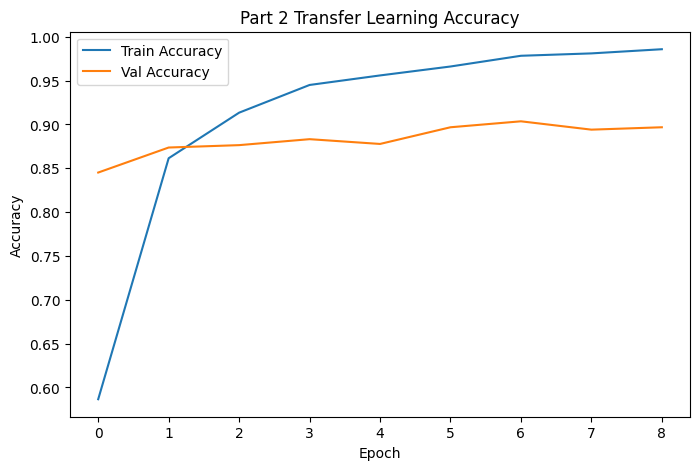

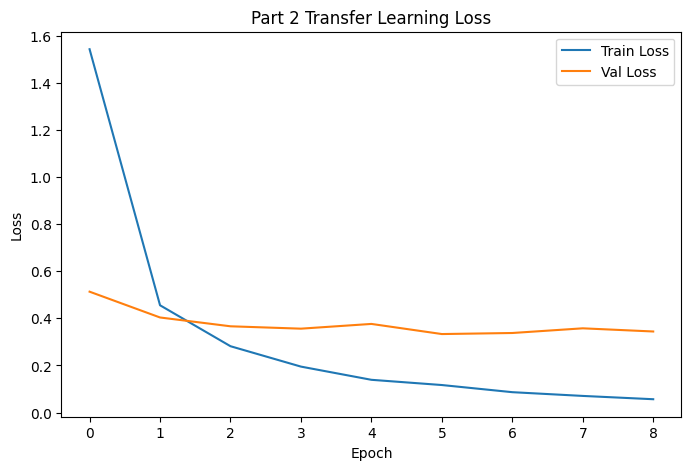

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history_transfer.history["accuracy"], label="Train Accuracy")
plt.plot(history_transfer.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Part 2 Transfer Learning Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_transfer.history["loss"], label="Train Loss")
plt.plot(history_transfer.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part 2 Transfer Learning Loss")
plt.legend()
plt.show()

**summary**
<br>
training accuracy increases rapidly and reaches about 99%, indicating the model learns the training data very well. Val accuracy improves early but then plateaus with only minor fluctuations, suggesting the model generalizes fairly well but stops improving after a few epochs.  
<br>
training loss decreases consistently toward near zero, showing strong fitting to the training data. Val loss decreases initially but then stabilizes with only slight fluctuations. This indicates reduced generalization gains and the beginnings of mild overfitting.  
<br>
overall, the model achieves high training performance but shows a gap between training and val metrics, with mild overfitting after early epochs and best generalization happening at around epochs 2-4.

**compute MobileNetV2 metrics**

In [16]:
test_loss_tl, test_accuracy_tl = transfer_model.evaluate(test_ds_mn, verbose=0)

y_true_tl = np.concatenate([labels.numpy() for _, labels in test_ds_mn], axis=0)
y_pred_probs_tl = transfer_model.predict(test_ds_mn)
y_pred_tl = np.argmax(y_pred_probs_tl, axis=1)

precision_tl = precision_score(y_true_tl, y_pred_tl, average="weighted", zero_division=0)
recall_tl = recall_score(y_true_tl, y_pred_tl, average="weighted", zero_division=0)
f1_tl = f1_score(y_true_tl, y_pred_tl, average="weighted", zero_division=0)

print("Part 2 Results")
print("Test Loss:", test_loss_tl)
print("Test Accuracy:", test_accuracy_tl)
print("Weighted Precision:", precision_tl)
print("Weighted Recall:", recall_tl)
print("Weighted F1 Score:", f1_tl)

115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step
Part 2 Results
Test Loss: 0.4387955665588379
Test Accuracy: 0.86045241355896
Weighted Precision: 0.8682191030934976
Weighted Recall: 0.860452439356773
Weighted F1 Score: 0.8596979215133709


**evaluate metrics**
<br>
The transfer learning model achieves strong overall performance with a test accuracy of 86% and a weighted F1 score of .86, indicating a good balance between precision and recall across all classes. The test loss is relatively low at .43, showing the model generalizes well to unseen data. Overall, these results demonstrate that MobileNetV2 transfer learning provides effective and stable performance for this task with consistent metrics across precision, recall, and f1.

**comparison between part 1 and part 2**
<br>
Compared to Part 1, the transfer learning model in Part 2 achieves higher and more stable performance across all metrics, including accuracy and weighted F1 score. This improvement is due to how MobileNetV2 uses pretrained ImageNet features, which provide strong visual representations that the custom CNN in Part 1 had to learn from scratch. As a result, Part 2 generalizes better and converges faster, while Part 1 suffered from lower accuracy and less stable performance likely due to limited data and training capacity. The smaller gap between precision, recall, and F1 in Part 2 also indicates more balanced predictions across classes. Overall, the differences highlight the effectiveness of transfer learning in improving performance and generalization on image classification tasks.

## Part 3

**define augmentation layers**

In [17]:
# data augmentation pipeline to apply random transformations to training images during training to induce dataset diversity and improve generalization
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"), # randomly flip images horizontal
    layers.RandomRotation(0.1), # randomly rotate images up to +- 10%; small enough rotation to add variety without distorting image too much
    layers.RandomZoom(0.1) # randomly zoom in/out by up to +- 10% (scale invariance)
])

**build augmented CNN model**

In [18]:
augmented_cnn_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    data_augmentation, # apply the random transformations

    # first conv layer using 32 3x3 filters to detect simple low-level features; standard to capture features well without unnecessary complexity
    layers.Conv2D(32, (3, 3), activation="relu"),
    # reduce dimensions by taking the max value in each 2x2 region. Reduces computations, keeps strongest features, and strengthens model against small position changes
    layers.MaxPooling2D((2, 2)),

    # second conv layer with 64 filters; deeper layers should learn more complex patterns than earlier
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)), # again reduce feature-map size and control model complexity

    # third conv layer with 128 filters to capture high-level, hyperspecific features
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)), # further compress feature maps before entering dense layers

    layers.Flatten(), # convert 2D feature maps into a 1D vector so they can be passed into dense layers for classification
    # fully connected layer that combines learned features before final prediction
    layers.Dense(128, activation="relu"), # large enough to learn useful feature combos, but not unncessarily large
    layers.Dropout(0.3), # standard dropout
    layers.Dense(NUM_CLASSES, activation="softmax") # final output layer
])

augmented_cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,406,565 (20.62 MB)

 Trainable params: 5,406,565 (20.62 MB)

 Non-trainable params: 0 (0.00 B)

**summary**
<br>
This architecture is a standard CNN that progressively learns more complex features through three pooling blocks, reducing spatial size while increasing feature depth. Most of the model's parameters are concentrated in the dense layer after flattening, which increases learning capacity but also raises the risk of overfitting, making dropout important. Overall, it is a simple yet effective design for multiclass image classification, balancing performance and computational efficiency.

**compile and train augmented CNN**

In [19]:
augmented_cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_aug = augmented_cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.0316 - loss: 3.6167 - val_accuracy: 0.0503 - val_loss: 3.6029
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0455 - loss: 3.5619 - val_accuracy: 0.0503 - val_loss: 3.5565
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.0581 - loss: 3.4877 - val_accuracy: 0.0666 - val_loss: 3.4392


**plot learning curves**

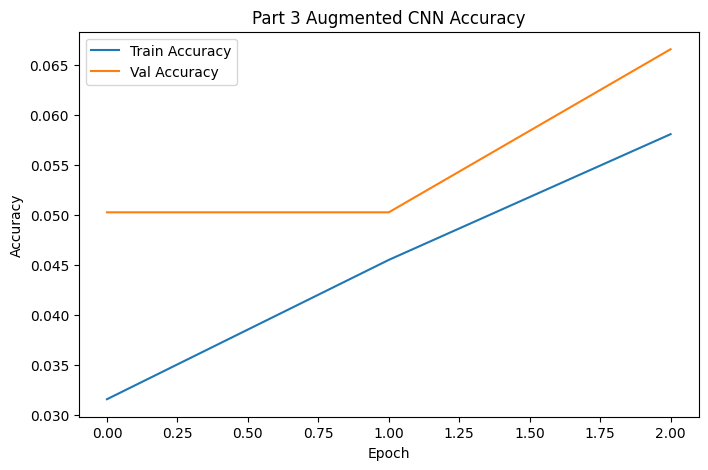

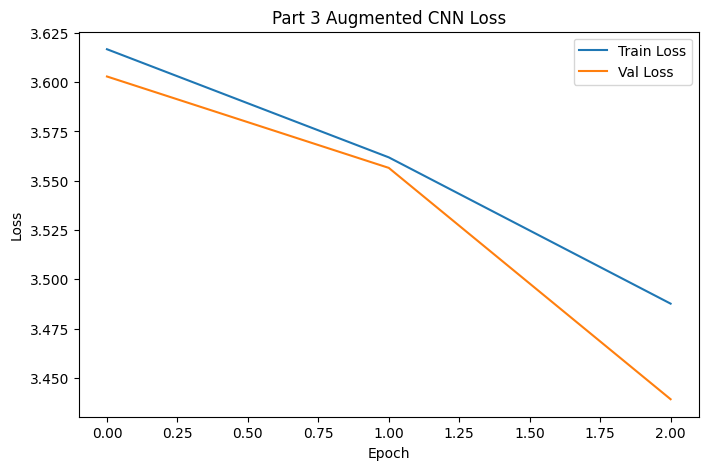

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history_aug.history["accuracy"], label="Train Accuracy")
plt.plot(history_aug.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Part 3 Augmented CNN Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_aug.history["loss"], label="Train Loss")
plt.plot(history_aug.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part 3 Augmented CNN Loss")
plt.legend()
plt.show()

**summary**
<br>
The learning curves show that both training and validation accuracy steadily increase while loss consistently decreases, indicating that the model is learning effectively. Validation accuracy remains higher than training accuracy, which suggests that data augmentation is successfully regularizing the model and improving generalization. However, overall accuracy remains low and the curves don't plateau, indicating the model is still underfitting and would likely benefit from more training epochs or increased model capacity. Fixes that may address this are increasing the number of epochs to 10-20 and potentially increasing the model capacity by addings another conv layer. This would allow the model enough time and flexibility to learn from the more diverse augmented data, reducing underfitting and improving performance.

**compute and evaluate metrics**

In [21]:
test_loss_aug, test_accuracy_aug = augmented_cnn_model.evaluate(test_ds, verbose=0)

y_true_aug = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)
y_pred_probs_aug = augmented_cnn_model.predict(test_ds)
y_pred_aug = np.argmax(y_pred_probs_aug, axis=1)

precision_aug = precision_score(y_true_aug, y_pred_aug, average="weighted", zero_division=0)
recall_aug = recall_score(y_true_aug, y_pred_aug, average="weighted", zero_division=0)
f1_aug = f1_score(y_true_aug, y_pred_aug, average="weighted", zero_division=0)

print("Part 3 Results")
print("Test Loss:", test_loss_aug)
print("Test Accuracy:", test_accuracy_aug)
print("Weighted Precision:", precision_aug)
print("Weighted Recall:", recall_aug)
print("Weighted F1 Score:", f1_aug)

115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
Part 3 Results
Test Loss: 3.6015074253082275
Test Accuracy: 0.047969475388526917
Weighted Precision: 0.012122996933424694
Weighted Recall: 0.047969473971109296
Weighted F1 Score: 0.015233578306546246


**comparison of part 3 to part 1**
<br>
Compared to Part 1, performance in Part 3 is significantly worse across all metrics, with very low accuracy and near-zero precision and F1 score. This suggests the model is underfitting, likely because data augmentation makes the training task more difficult by introducing additional variability in the images. While augmentation is intended to improve generalization, in this case the model has not trained long enough or is not complex enough to learn effectively from the more diverse data. As a result, the benefits of augmentation don't shine through in this task, leading to lower performance compared to Part 1.


**final summary table**

In [22]:
print("Final Summary\n")
print("--Part 1: CNN from Scratch--")
print("Accuracy:", test_accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

print("\n--Part 2: Transfer Learning (MobileNetV2)--")
print("Accuracy:", test_accuracy_tl)
print("Precision:", precision_tl)
print("Recall:", recall_tl)
print("F1:", f1_tl)

print("\n--Part 3: CNN with Data Augmentation--")
print("Accuracy:", test_accuracy_aug)
print("Precision:", precision_aug)
print("Recall:", recall_aug)
print("F1:", f1_aug)

Final Summary

--Part 1: CNN from Scratch--
Accuracy: 0.08994276076555252
Precision: 0.08675628778450811
Recall: 0.08994276369582993
F1: 0.07001712805180652

--Part 2: Transfer Learning (MobileNetV2)--
Accuracy: 0.86045241355896
Precision: 0.8682191030934976
Recall: 0.860452439356773
F1: 0.8596979215133709

--Part 3: CNN with Data Augmentation--
Accuracy: 0.047969475388526917
Precision: 0.012122996933424694
Recall: 0.047969473971109296
F1: 0.015233578306546246


**conclusion**
<br>
The CNN from scratch (Part 1) achieved low performance (only 10% accuracy), indicating limited ability to learn complex features from the dataset due to its relatively simple architecture and lack of prior knowledge. In contrast, the MobileNetV2 transfer learning model (Part 2) performed extremely well (86% accuracy), demonstrating the strength of pretrained features in capturing useful visual patterns learned from large-scale datasets. The augmented CNN (Part 3) performed the worst (3% accuracy), likely due to underfitting caused by increased data variability from augmentation combined with insufficient training time and model capacity. This highlights that while augmentation can improve generalization, it requires longer training and/or a stronger model to be effective. In the future, Part 1 and Part 3 could be improved by increasing epochs, tuning architecture, or using regularization techniques more carefully, but overall, transfer learning is clearly the most suitable approach for this task given its superior performance and efficiency.